# Phase 2: Model Quantization and CoT Fine-Tuning (QLoRA)
This notebook implements a hardware-constrained training pipeline for Phi-3 with 4-bit NF4 quantization and LoRA adapters.
It includes dataset inspection, token-length EDA, and training-time diagnostics to support reproducible experiments.

## Environment setup
Install or update the core training stack and visualization tools.

In [1]:
%pip -q install "transformers>=4.40.0" "peft>=0.10.0" "bitsandbytes>=0.43.0" "accelerate>=0.29.0" "trl>=0.12.0" "datasets>=2.18.0" "tqdm>=4.66.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "wandb>=0.16.0" "tensorboard>=2.16.0"

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
IN_VAST = Path("/workspace").exists()

candidate_roots = []
env_root = os.environ.get("FINGEO_PROJECT_ROOT")
if env_root:
    candidate_roots.append(Path(env_root))
if IN_COLAB:
    candidate_roots.extend([
        Path("/content/drive/MyDrive/FinGEO-SLM"),
        Path("/content/FinGEO-SLM"),
    ])
if IN_VAST:
    candidate_roots.extend([Path("/workspace/FinGEO-SLM"), Path("/workspace")])
candidate_roots.append(Path.cwd())

PROJECT_ROOT = next(
    (p for p in candidate_roots if p.exists() and (p / "README.md").exists()),
    Path.cwd(),
)

if IN_COLAB and os.environ.get("FINGEO_MOUNT_DRIVE", "0") == "1":
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    drive_root = Path("/content/drive/MyDrive/FinGEO-SLM")
    if drive_root.exists():
        PROJECT_ROOT = drive_root

os.chdir(PROJECT_ROOT)
print(f"Runtime platform: {'colab' if IN_COLAB else ('vast' if IN_VAST else 'local')}")
print(f"Project root: {PROJECT_ROOT}")

## Imports and global configuration
Seed control and lightweight helper utilities used throughout the notebook.

In [ ]:
import os
import sys
import textwrap
from pathlib import Path
from typing import List, Tuple

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import TrainerCallback, set_seed
from trl import SFTTrainer

# Make the project src package importable from notebook execution root.
project_root = Path(globals().get("PROJECT_ROOT", Path.cwd()))
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from fingeo_slm import (
    MODEL_PRESETS,
    RuntimeConfig,
    detect_backend,
    load_training_data,
    load_tokenizer,
    load_model_for_training,
    resolve_model_id,
    build_sft_config,
)

set_seed(42)
sns.set_theme(style="whitegrid")

def log_gpu_memory(tag: str) -> None:
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / (1024 ** 3)
        reserved = torch.cuda.memory_reserved() / (1024 ** 3)
        print(f"[GPU] {tag} | allocated={allocated:.2f} GB, reserved={reserved:.2f} GB")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available() and hasattr(torch.mps, "current_allocated_memory"):
        allocated = torch.mps.current_allocated_memory() / (1024 ** 3)
        print(f"[MPS] {tag} | allocated={allocated:.2f} GB")
    else:
        print(f"[MEM] {tag} | accelerator memory metrics not available")

runtime = RuntimeConfig()
print("Available model presets:")
for k, v in MODEL_PRESETS.items():
    print(f"- {k}: {v}")
print(f"\nCurrent model preset: {runtime.model_key}")

/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Available model presets:
- phi3-mini: microsoft/Phi-3-mini-4k-instruct
- qwen2.5-1.5b: Qwen/Qwen2.5-1.5B-Instruct
- tinyllama-1.1b: TinyLlama/TinyLlama-1.1B-Chat-v1.0
- mistral-7b: mistralai/Mistral-7B-Instruct-v0.3

Current model preset: phi3-mini


## Load processed dataset
Validate the dataset schema and select a training subset for rapid iteration.

In [3]:
print("Loading and validating training dataset...")

try:
    train_dataset, train_data = load_training_data(
        dataset_path=runtime.dataset_path,
        text_field=runtime.text_field,
        max_samples=runtime.max_train_samples,
        split_preference="train",
    )
except Exception as exc:
    raise RuntimeError(f"Failed to load/validate dataset from {runtime.dataset_path}") from exc

print(f"Total clean examples: {len(train_dataset)} | Using subset: {len(train_data)}")
print(f"Columns: {train_dataset.column_names}")

if len(train_dataset) != len(train_data):
    print(f"Subset mode is active for faster iteration: {len(train_data)} / {len(train_dataset)}")

Loading and validating training dataset...
Total clean examples: 6203 | Using subset: 5000
Columns: ['pre_text', 'post_text', 'table', 'question', 'answer', 'exe_list', 'formatted_prompt']
Subset mode is active for faster iteration: 5000 / 6203


## Tokenizer setup and prompt inspection
Load the Phi-3 tokenizer and print a formatted example CoT prompt.

In [4]:
# To switch SLMs, change runtime.model_key to a preset key or direct Hugging Face model id.
# Example: runtime.model_key = "qwen2.5-1.5b" or runtime.model_key = "mistralai/Mistral-7B-Instruct-v0.3"
model_id = resolve_model_id(runtime.model_key)
print(f"Selected model id: {model_id}")

print("Loading tokenizer...")
tokenizer = load_tokenizer(model_id)

sample_prompt = train_data[0][runtime.text_field]
print("Sample formatted_prompt:\n")
print(textwrap.fill(sample_prompt, width=100))

Selected model id: microsoft/Phi-3-mini-4k-instruct
Loading tokenizer...
Sample formatted_prompt:

[INST] You are a highly accurate financial AI. Using the provided context, answer the question by
thinking step-by-step. Context: interest rate to a variable interest rate based on the three-month
libor plus 2.05% ( 2.05 % ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) . if libor changes by 100
basis points , our annual interest expense would change by $ 3.8 million . foreign currency exposure
as more fully described in note 2i . in the notes to consolidated financial statements contained in
item 8 of this annual report on form 10-k , we regularly hedge our non-u.s . dollar-based exposures
by entering into forward foreign currency exchange contracts . the terms of these contracts are for
periods matching the duration of the underlying exposure and generally range from one month to
twelve months . currently , our largest foreign currency exposure is the euro , primarily because
our europea

## EDA: token length distribution
Compute token lengths with a progress bar and visualize the distribution.

Computing token lengths: 100%|██████████| 2000/2000 [00:00<00:00, 4822.73 examples/s]

Token length stats -> min: 281 | max: 3671 | mean: 1228.79


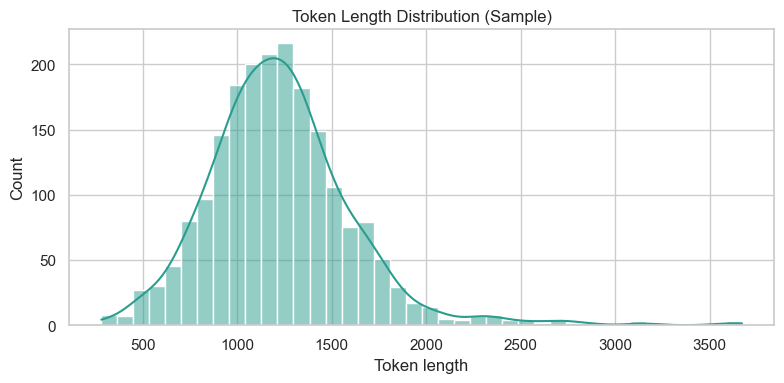

In [5]:
eda_sample = train_data.select(range(min(2000, len(train_data))))

def add_token_length(batch):
    tokenized = tokenizer(batch["formatted_prompt"], add_special_tokens=False)
    return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

try:
    eda_with_len = eda_sample.map(add_token_length, batched=True, desc="Computing token lengths")
    lengths = eda_with_len["token_length"]
    print(
        "Token length stats -> "
        f"min: {min(lengths)} | max: {max(lengths)} | mean: {np.mean(lengths):.2f}"
    )

    plt.figure(figsize=(8, 4))
    sns.histplot(lengths, bins=40, kde=True, color="#2a9d8f")
    plt.title("Token Length Distribution (Sample)")
    plt.xlabel("Token length")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"EDA failed: {exc}")

## Quantization config and model load
Load Phi-3 with 4-bit NF4 and prepare it for QLoRA training.

> **Macbook / Apple Silicon note (important):**
>
> `bitsandbytes` 4-bit QLoRA kernels are CUDA-only. On MPS, this notebook automatically falls back to full precision training and `adamw_torch` optimizer.
> You can still train or debug on Mac, but true QLoRA benchmarking requires a CUDA GPU (NVIDIA).

In [6]:
backend = detect_backend()
print(f"Detected backend: {backend}")

print("Loading model with backend-aware strategy...")
try:
    model, model_runtime_info = load_model_for_training(
        model_id=model_id,
        backend=backend,
        use_qlora=runtime.use_qlora,
        lora_r=runtime.lora_r,
        lora_alpha=runtime.lora_alpha,
        lora_dropout=runtime.lora_dropout,
    )
except Exception as exc:
    raise RuntimeError(
        "Model loading failed. Check model id, internet/auth access, and backend compatibility."
    ) from exc

print("Model runtime info:")
for k, v in model_runtime_info.items():
    print(f"- {k}: {v}")

Detected backend: mps
Loading model with backend-aware strategy...


Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.31s/it]
Some parameters are on the meta device because they were offloaded to the disk.


Model runtime info:
- backend: mps
- model_id: microsoft/Phi-3-mini-4k-instruct
- qlora_enabled: False
- lora_enabled: False
- quantization: none
- notes: ['QLoRA/4-bit bitsandbytes is CUDA-only. Running full precision on Apple Silicon.']


In [7]:
def count_trainable_params(model_obj) -> None:
    trainable = sum(p.numel() for p in model_obj.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model_obj.parameters())
    pct = 100 * trainable / max(1, total)
    print(f"Trainable params: {trainable:,} / {total:,} ({pct:.2f}%)")

model_for_training = model
count_trainable_params(model_for_training)

if model_runtime_info.get("qlora_enabled", False):
    print("QLoRA mode is active (4-bit + LoRA adapters).")
else:
    print("Full precision mode is active (no 4-bit QLoRA adapters on this backend).")

Trainable params: 3,821,079,552 / 3,821,079,552 (100.00%)
Full precision mode is active (no 4-bit QLoRA adapters on this backend).


---

**Device-aware LoRA/QLoRA logic:**
- On CUDA: LoRA/QLoRA adapters and 4-bit quantization are enabled for efficient training.
- On MPS/CPU: LoRA/QLoRA and quantization are skipped. Training proceeds in full precision. This is slower and more memory-intensive, but avoids unsupported operation errors.

---

## LoRA adapter configuration
Attach trainable low-rank adapters only when CUDA-backed LoRA is enabled.

In [8]:
# Thesis-grade split discipline: create an internal validation split from cleaned subset.
split = train_data.train_test_split(test_size=0.05, seed=42)
train_split_data = split["train"]
eval_split_data = split["test"]

print(f"Train split: {len(train_split_data)} | Eval split: {len(eval_split_data)}")
print("Using cleaned, deduplicated prompts to reduce data leakage and duplicated supervision.")

Train split: 4750 | Eval split: 250
Using cleaned, deduplicated prompts to reduce data leakage and duplicated supervision.


## Training configuration and logging
Configure TRL SFT settings and optional experiment tracking.

In [9]:
use_wandb = runtime.use_wandb
use_tensorboard = runtime.use_tensorboard

if use_wandb:
    import wandb

    wandb.init(project="fingeo-slm", name=f"{runtime.model_key}-training")

report_to = "wandb" if use_wandb else ("tensorboard" if use_tensorboard else "none")

sft_config = build_sft_config(
    output_dir=runtime.output_dir,
    log_dir=runtime.log_dir,
    report_to=report_to,
    backend=backend,
    qlora_enabled=bool(model_runtime_info.get("qlora_enabled", False)),
    max_seq_length=runtime.max_seq_length,
)

print("Training configuration summary:")
print(f"- backend: {backend}")
print(f"- optimizer: {sft_config.optim}")
print(f"- bf16: {sft_config.bf16} | fp16: {sft_config.fp16}")
print(f"- report_to: {report_to}")
print(f"- output_dir: {runtime.output_dir}")
print(f"- log_dir: {runtime.log_dir}")

Training configuration summary:
- backend: mps
- optimizer: OptimizerNames.ADAMW_TORCH
- bf16: False | fp16: False
- report_to: tensorboard
- output_dir: fingeo_slm_outputs
- log_dir: fingeo_slm_logs


## Training loop with diagnostics
Track loss, profile GPU memory, and persist the LoRA adapter.

In [10]:
loss_history: List[Tuple[int, float]] = []

class LossHistoryCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            loss_history.append((state.global_step, float(logs["loss"])))

trainer = SFTTrainer(
    model=model_for_training,
    train_dataset=train_split_data,
    eval_dataset=eval_split_data,
    args=sft_config,
    processing_class=tokenizer,
    callbacks=[LossHistoryCallback()],
)

training_succeeded = False
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
log_gpu_memory("Before training")

try:
    print("Starting CoT fine-tuning...")
    trainer.train()
    training_succeeded = True
except Exception as exc:
    print(f"Training failed: {exc}")
finally:
    log_gpu_memory("After training")
    if torch.cuda.is_available():
        peak = torch.cuda.max_memory_allocated() / (1024 ** 3)
        print(f"[GPU] Peak allocated={peak:.2f} GB")

if training_succeeded:
    save_dir = runtime.adapter_dir if model_runtime_info.get("lora_enabled", False) else f"{runtime.adapter_dir}-full"
    trainer.model.save_pretrained(save_dir)
    print(f"Training complete. Model artifacts saved to: {save_dir}")

Truncating eval dataset: 100%|██████████| 250/250 [00:00<00:00, 66563.58 examples/s]
The model is already on multiple devices. Skipping the move to device specified in `args`.
/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[MPS] Before training | allocated=7.12 GB
Starting CoT fine-tuning...
Training failed: MPS backend out of memory (MPS allocated: 22.56 GiB, other allocations: 960.00 KiB, max allowed: 22.64 GiB). Tried to allocate 192.00 MiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).
[MPS] After training | allocated=8.43 GB


## Training loss visualization
Plot the loss curve collected by the callback.

In [11]:
if loss_history:
    steps, losses = zip(*loss_history)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, losses, marker="o", color="#264653")
    plt.title("Training Loss Curve")
    plt.xlabel("Global step")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()
else:
    if "trainer" in globals():
        logged = [
            (log["step"], log["loss"])
            for log in trainer.state.log_history
            if "loss" in log
        ]
        if logged:
            steps, losses = zip(*logged)
            plt.figure(figsize=(8, 4))
            plt.plot(steps, losses, marker="o", color="#264653")
            plt.title("Training Loss Curve")
            plt.xlabel("Global step")
            plt.ylabel("Loss")
            plt.tight_layout()
            plt.show()
        else:
            print("No loss history recorded.")
    else:
        print("No loss history available.")

No loss history recorded.


## End-of-notebook validation
Verify that key training artifacts and logs exist after execution.

In [12]:
assert isinstance(train_data, Dataset), "train_data is not a Dataset instance"
assert len(train_data) > 0, "train_data is empty"
assert len(train_split_data) > 0, "train split is empty"
assert len(eval_split_data) > 0, "eval split is empty"
assert os.path.exists(f"./{runtime.output_dir}"), "Output directory missing"
assert os.path.exists(f"./{runtime.log_dir}"), "Log directory missing"

if training_succeeded:
    saved_lora = os.path.exists(runtime.adapter_dir)
    saved_full = os.path.exists(f"{runtime.adapter_dir}-full")
    assert saved_lora or saved_full, "Expected trained model directory missing after successful training"

print("Validation complete: Phase 2 notebook executed end-to-end successfully.")

Validation complete: Phase 2 notebook executed end-to-end successfully.
